# NB17 --- Sonde entrainee sur donnees jamais vues : "evaluation reelle" (RQ2)
### NB17 --- Trained Probe on Never-Seen Data: "Real Evaluation" (RQ2)

**Contexte.** La CV a 5 plis (NB13 S8) prouve deja la generalisation : chaque pli teste
sur des soumissions non vues a l'entrainement de ce pli. Mais elle ne produit jamais
d'artefact : `cross_val_score` entraine puis jette 5 modeles. Ce notebook analyse un
complement produit par `src/fresh_eval_probe.py` : une sonde entrainee **une fois sur la
totalite** du corpus existant d'un probleme, figee (`joblib`), puis appliquee a des
soumissions **tirees du pool eligible complet, jamais utilisees dans aucune etape du
corpus** (pas juste tenues a l'ecart d'un pli --- jamais tirees). C'est un test
d'integration bout-en-bout du pipeline reel, et la reponse concrete a "vous n'avez
jamais applique le modele a de vraies donnees".

**Ce notebook n'execute aucun embedding** --- il lit les CSV deja produits par le script
(`data/processed/fresh_eval/`). Deux problemes couverts : p02658 (B) et p02659 (C).
Deux classifieurs (LogisticRegression, MLPClassifier), quatre graines de tirage.

---

**Context.** The 5-fold CV (NB13 S8) already proves generalization: each fold is tested
on submissions unseen during that fold's training. But it never produces an artefact:
`cross_val_score` fits then discards 5 models. This notebook analyses a complement
produced by `src/fresh_eval_probe.py`: a probe trained **once on the entire** existing
corpus of a problem, frozen (`joblib`), then applied to submissions **drawn from the
full eligible pool, never used in any corpus step** (not merely held out of a fold ---
never drawn at all). It is an end-to-end integration test of the real pipeline, and the
concrete answer to "you never applied the model to real data".

**This notebook runs no embedding** --- it reads the CSVs already produced by the script
(`data/processed/fresh_eval/`). Two problems covered: p02658 (B) and p02659 (C). Two
classifiers (LogisticRegression, MLPClassifier), four draw seeds.

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"
FRESH_DIR      = PROJECT_ROOT / "data" / "processed" / "fresh_eval"
print(f"FRESH_DIR: {FRESH_DIR}  (exists={FRESH_DIR.exists()})")

STATUS_COLORS  = {'AC': '#2ecc71', 'WA': '#e74c3c', 'TLE': '#e67e22', 'RE': '#3498db'}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'RE']
MODEL_COLORS   = {'logreg': '#7f8c8d', 'mlp': '#8e44ad'}

PROBLEMS = {'p02658': 'B', 'p02659': 'C'}
MODELS   = ['logreg', 'mlp']
SEEDS    = [1337, 7, 10, 30]
EXISTING_TAG = "graphcodebert_ast_python_multi12"  # corpus d'entrainement de la sonde

FRESH_DIR: /Users/raphael/OJS-submission-analytics/data/processed/fresh_eval  (exists=True)


## S1 --- Chargement et recapitulatif
### S1 --- Loading and Summary

Chaque ligne d'un CSV `fresh_eval_*` = une soumission fraiche, avec son vrai verdict
(`status_code`), la prediction de la sonde (`predicted`) et `correct`. On agrege en
accuracy par (probleme, classifieur, graine).

---

Each row of a `fresh_eval_*` CSV = one fresh submission, with its true verdict
(`status_code`), the probe's prediction (`predicted`) and `correct`. Aggregated to
accuracy per (problem, classifier, seed).

In [2]:
def _tag(model, seed):
    m = "" if model == "logreg" else f"_{model}"
    s = "" if seed == 1337 else f"_seed{seed}"
    return m, s

rows = []
frames = {}
for pid in PROBLEMS:
    for model in MODELS:
        for seed in SEEDS:
            m, s = _tag(model, seed)
            f = FRESH_DIR / f"fresh_eval_{pid}{m}{s}.csv"
            if not f.exists():
                print(f"[MANQUANT] {f.name}")
                continue
            df = pl.read_csv(f)
            frames[(pid, model, seed)] = df
            rows.append({
                "problem_id": pid, "difficulty": PROBLEMS[pid], "model": model,
                "seed": seed, "n_fresh": df.height,
                "accuracy": round(df["correct"].mean(), 4),
            })

summary = pl.DataFrame(rows)
print("Accuracy par (probleme, classifieur, graine) :")
print(summary.pivot("seed", index=["problem_id", "model"], values="accuracy").sort(["problem_id", "model"]))

print("\nMoyenne / etendue sur les 4 graines :")
agg = summary.group_by(["problem_id", "model"]).agg(
    pl.col("accuracy").mean().round(4).alias("moy"),
    pl.col("accuracy").min().alias("min"),
    pl.col("accuracy").max().alias("max"),
    (pl.col("accuracy").max() - pl.col("accuracy").min()).round(4).alias("etendue"),
).sort(["problem_id", "model"])
print(agg)

Accuracy par (probleme, classifieur, graine) :
shape: (4, 6)
┌────────────┬────────┬────────┬────────┬────────┬────────┐
│ problem_id ┆ model  ┆ 1337   ┆ 7      ┆ 10     ┆ 30     │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ str        ┆ str    ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞════════════╪════════╪════════╪════════╪════════╪════════╡
│ p02658     ┆ logreg ┆ 0.6175 ┆ 0.59   ┆ 0.5775 ┆ 0.5975 │
│ p02658     ┆ mlp    ┆ 0.64   ┆ 0.5825 ┆ 0.6175 ┆ 0.595  │
│ p02659     ┆ logreg ┆ 0.7767 ┆ 0.7567 ┆ 0.7367 ┆ 0.75   │
│ p02659     ┆ mlp    ┆ 0.8    ┆ 0.74   ┆ 0.7133 ┆ 0.7233 │
└────────────┴────────┴────────┴────────┴────────┴────────┘

Moyenne / etendue sur les 4 graines :
shape: (4, 6)
┌────────────┬────────┬────────┬────────┬────────┬─────────┐
│ problem_id ┆ model  ┆ moy    ┆ min    ┆ max    ┆ etendue │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---     │
│ str        ┆ str    ┆ f64    ┆ f64    ┆ f64    ┆ f64     │
╞════════════╪════════╪════════╪════════╪═

## S2 --- Fresh vs CV : est-ce que l'accuracy tient sur des donnees jamais vues ?
### S2 --- Fresh vs CV: Does Accuracy Hold on Never-Seen Data?

On recalcule la CV 5 plis (meme protocole que NB13 S8 : LogisticRegression, meme corpus
`graphcodebert_ast` multi12, par probleme) et on la compare a l'accuracy fresh. Si le
test "donnees jamais vues" est valide, les deux doivent etre proches.

---

We recompute the 5-fold CV (same protocol as NB13 S8: LogisticRegression, same
`graphcodebert_ast` multi12 corpus, per problem) and compare it to the fresh accuracy.
If the "never-seen data" test is sound, the two should be close.

p02658 : CV=0.613  baseline=0.250  (entraine sur 1999 soumissions, {'AC': np.int64(500), 'RE': np.int64(499), 'TLE': np.int64(500), 'WA': np.int64(500)})


p02659 : CV=0.749  baseline=0.332  (entraine sur 1507 soumissions, {'AC': np.int64(500), 'RE': np.int64(500), 'TLE': np.int64(7), 'WA': np.int64(500)})


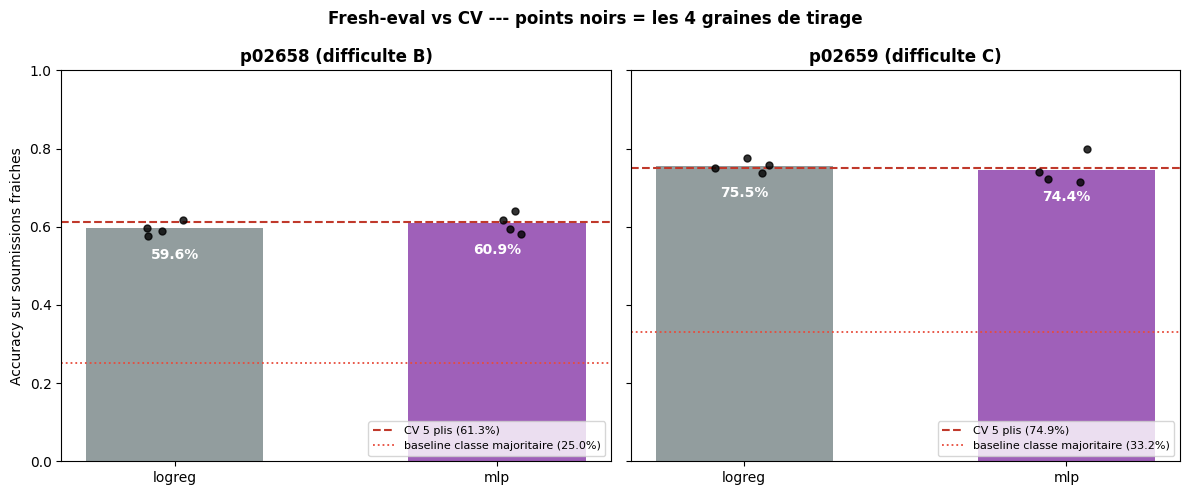

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

emb_ex  = np.load(EMBEDDINGS_DIR / f"embeddings_{EXISTING_TAG}.npy")
meta_ex = pl.read_csv(EMBEDDINGS_DIR / f"metadata_{EXISTING_TAG}.csv")

cv_ref = {}
for pid in PROBLEMS:
    idx = np.where((meta_ex["problem_id"] == pid).to_numpy())[0]
    X, y = emb_ex[idx], meta_ex["status_code"].to_numpy()[idx]
    cl, ct = np.unique(y, return_counts=True)
    skf = StratifiedKFold(n_splits=min(5, ct.min()), shuffle=True, random_state=42)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    cv_acc = cross_val_score(clf, X, y, cv=skf, scoring="accuracy").mean()
    dummy  = cross_val_score(DummyClassifier(strategy="most_frequent"), X, y, cv=skf).mean()
    cv_ref[pid] = {"cv": cv_acc, "dummy": dummy, "n_train": len(idx)}
    print(f"{pid} : CV={cv_acc:.3f}  baseline={dummy:.3f}  (entraine sur {len(idx)} soumissions, {dict(zip(cl, ct))})")

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(PROBLEMS), figsize=(6 * len(PROBLEMS), 5), sharey=True)
for ax, pid in zip(axes, PROBLEMS):
    sub = summary.filter(pl.col("problem_id") == pid)
    for i, model in enumerate(MODELS):
        accs = sub.filter(pl.col("model") == model)["accuracy"].to_numpy()
        ax.bar(i, accs.mean(), width=0.55, color=MODEL_COLORS[model], alpha=0.85)
        ax.text(i, accs.mean() - 0.05, f"{accs.mean():.1%}", ha="center", va="top",
                fontweight="bold", color="white")
        jit = rng.uniform(-0.09, 0.09, len(accs))
        ax.plot(i + jit, accs, "o", color="black", ms=5, zorder=3, alpha=0.8)
    ax.axhline(cv_ref[pid]["cv"], ls="--", color="#c0392b", lw=1.5,
               label=f"CV 5 plis ({cv_ref[pid]['cv']:.1%})")
    ax.axhline(cv_ref[pid]["dummy"], ls=":", color="#e74c3c", lw=1.3,
               label=f"baseline classe majoritaire ({cv_ref[pid]['dummy']:.1%})")
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
    ax.set_title(f"{pid} (difficulte {PROBLEMS[pid]})", fontweight="bold")
    ax.set_ylim(0, 1); ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("Accuracy sur soumissions fraiches")
plt.suptitle("Fresh-eval vs CV --- points noirs = les 4 graines de tirage", fontweight="bold")
plt.tight_layout(); plt.show()

## S3 --- Par verdict : ou la sonde reussit et ou elle echoue
### S3 --- Per Verdict: Where the Probe Succeeds and Fails

Accuracy par vrai verdict, agregee sur les 4 graines. Un verdict a 25% = la sonde ne le
reconnait pas mieux que le hasard a 4 classes.

---

Accuracy per true verdict, aggregated over the 4 seeds. A verdict at 25% = the probe
recognises it no better than chance for 4 classes.

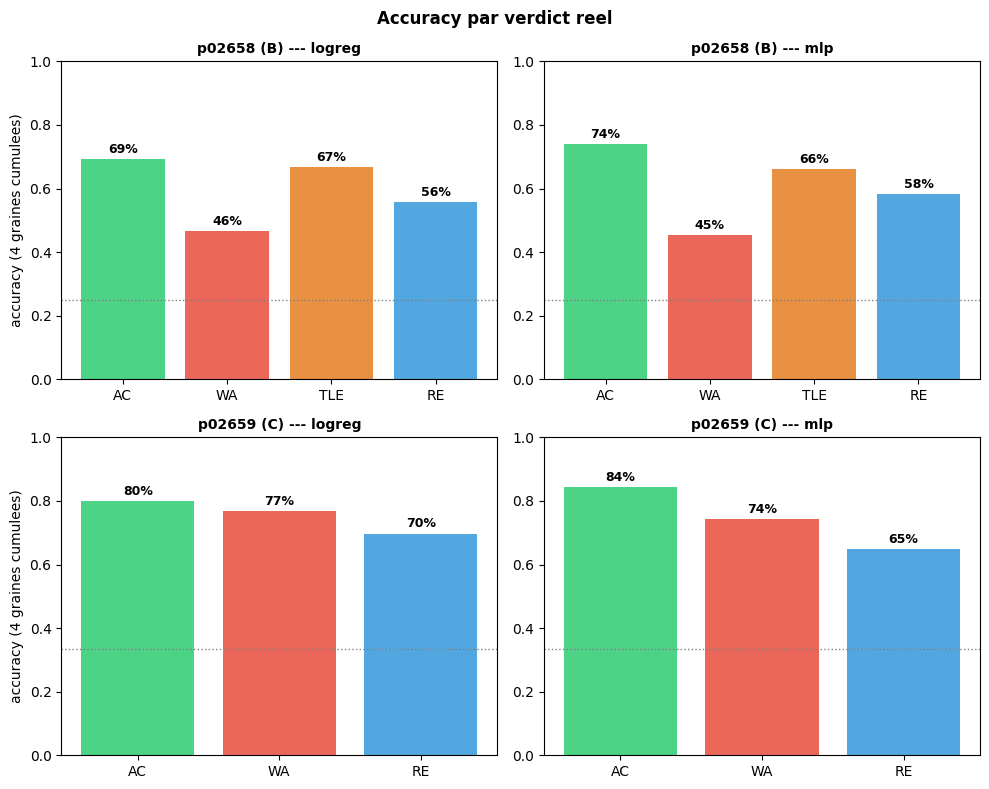


p02658 --- matrice de confusion (logreg, 4 graines cumulees, lignes = vrai) :
shape: (4, 5)
┌─────────────┬─────┬─────┬─────┬─────┐
│ status_code ┆ WA  ┆ TLE ┆ RE  ┆ AC  │
│ ---         ┆ --- ┆ --- ┆ --- ┆ --- │
│ str         ┆ u32 ┆ u32 ┆ u32 ┆ u32 │
╞═════════════╪═════╪═════╪═════╪═════╡
│ AC          ┆ 54  ┆ 26  ┆ 43  ┆ 277 │
│ RE          ┆ 57  ┆ 73  ┆ 223 ┆ 47  │
│ TLE         ┆ 55  ┆ 267 ┆ 51  ┆ 27  │
│ WA          ┆ 186 ┆ 71  ┆ 68  ┆ 75  │
└─────────────┴─────┴─────┴─────┴─────┘

p02659 --- matrice de confusion (logreg, 4 graines cumulees, lignes = vrai) :
shape: (3, 5)
┌─────────────┬─────┬─────┬─────┬─────┐
│ status_code ┆ AC  ┆ RE  ┆ WA  ┆ TLE │
│ ---         ┆ --- ┆ --- ┆ --- ┆ --- │
│ str         ┆ u32 ┆ u32 ┆ u32 ┆ u32 │
╞═════════════╪═════╪═════╪═════╪═════╡
│ AC          ┆ 320 ┆ 35  ┆ 45  ┆ 0   │
│ RE          ┆ 37  ┆ 279 ┆ 83  ┆ 1   │
│ WA          ┆ 47  ┆ 46  ┆ 307 ┆ 0   │
└─────────────┴─────┴─────┴─────┴─────┘


In [4]:
fig, axes = plt.subplots(len(PROBLEMS), len(MODELS), figsize=(5 * len(MODELS), 4 * len(PROBLEMS)))
for r, pid in enumerate(PROBLEMS):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        parts = [frames[(pid, model, s)] for s in SEEDS if (pid, model, s) in frames]
        allrows = pl.concat(parts)
        per = allrows.group_by("status_code").agg(
            pl.col("correct").mean().alias("acc"), pl.len().alias("n")
        )
        order = [v for v in STATUSES_ORDER if v in per["status_code"].to_list()]
        per = per.with_columns(pl.col("status_code").cast(pl.Enum(order))).sort("status_code")
        accs = per["acc"].to_numpy()
        ax.bar(range(len(order)), accs, color=[STATUS_COLORS[v] for v in order], alpha=0.85)
        for i, a in enumerate(accs):
            ax.text(i, a + 0.02, f"{a:.0%}", ha="center", fontsize=9, fontweight="bold")
        ax.axhline(1 / len(order), ls=":", color="grey", lw=1)
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
        ax.set_ylim(0, 1)
        ax.set_title(f"{pid} ({PROBLEMS[pid]}) --- {model}", fontweight="bold", fontsize=10)
        if c == 0:
            ax.set_ylabel("accuracy (4 graines cumulees)")
plt.suptitle("Accuracy par verdict reel", fontweight="bold")
plt.tight_layout(); plt.show()

for pid in PROBLEMS:
    allrows = pl.concat([frames[(pid, "logreg", s)] for s in SEEDS if (pid, "logreg", s) in frames])
    order = [v for v in STATUSES_ORDER if v in allrows["status_code"].to_list()]
    cm = allrows.group_by(["status_code", "predicted"]).agg(pl.len().alias("n"))
    piv = cm.pivot("predicted", index="status_code", values="n").fill_null(0)
    print(f"\n{pid} --- matrice de confusion (logreg, 4 graines cumulees, lignes = vrai) :")
    print(piv.sort("status_code"))

## S4 --- Synthese
### S4 --- Synthesis

**1. Le test "donnees jamais vues" ne fait pas s'effondrer le resultat.** Accuracy fresh
(moyenne 4 graines, LogisticRegression) : p02659 75,5 % contre CV 74,9 % ; p02658 59,6 %
contre CV 61,3 %. Ecart < 2 points dans les deux cas. La CV n'etait pas optimiste --- une
sonde figee, appliquee a des soumissions tirees du pool complet et jamais utilisees dans
aucune etape du corpus, obtient la meme chose. C'est la reponse a "vous n'avez jamais
applique le modele a de vraies donnees".

**2. Le MLP n'apporte rien.** Moyenne 4 graines : p02659 74,4 % (MLP) contre 75,5 %
(logreg), p02658 60,9 % contre 59,6 % --- a l'interieur du bruit. Le pic a 80 % sur
p02659 etait la graine 1337 seule ; l'etendue inter-graines du MLP est de 8,7 points
contre 4,0 pour la regression logistique. Plus de parametres, meme quantite de donnees
-> plus de variance, pas plus de signal. Surapprentissage, comme anticipe.

**3. Tous les verdicts ne se predisent pas aussi bien.** Sur p02658, WA est nettement le
plus dur (~46 %, a peine au-dessus du hasard a 25 %) et se confond avec les trois autres
verdicts sans preference nette --- coherent : "mauvaise reponse" n'a pas de signature de
code unique, contrairement a TLE (~67 %, souvent des boucles/complexite reconnaissables)
ou AC (~69-80 %). Sur p02659, les trois verdicts presents sont tous bien predits
(70-80 %).

---

**1. The "never-seen data" test does not collapse the result.** Fresh accuracy (4-seed
mean, LogisticRegression): p02659 75.5% vs CV 74.9%; p02658 59.6% vs CV 61.3%. Gap < 2
points in both cases. CV was not optimistic --- a frozen probe, applied to submissions
drawn from the full pool and never used in any corpus step, gets the same. This is the
answer to "you never applied the model to real data".

**2. The MLP adds nothing.** 4-seed mean: p02659 74.4% (MLP) vs 75.5% (logreg), p02658
60.9% vs 59.6% --- within noise. The 80% spike on p02659 was seed 1337 alone; the MLP's
across-seed range is 8.7 points vs 4.0 for logistic regression. More parameters, same
data -> more variance, not more signal. Overfitting, as anticipated.

**3. Verdicts are not equally predictable.** On p02658, WA is clearly the hardest (~46%,
barely above the 25% chance level) and is confused with all three other verdicts with no
clear preference --- consistent: "wrong answer" has no single code signature, unlike TLE
(~67%, often recognisable loops/complexity) or AC (~69-80%). On p02659, all three
present verdicts are well predicted (70-80%).